In [4]:
import os
import json
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

TEST_DIR = "./test-videos"

Found 13 anomaly score files


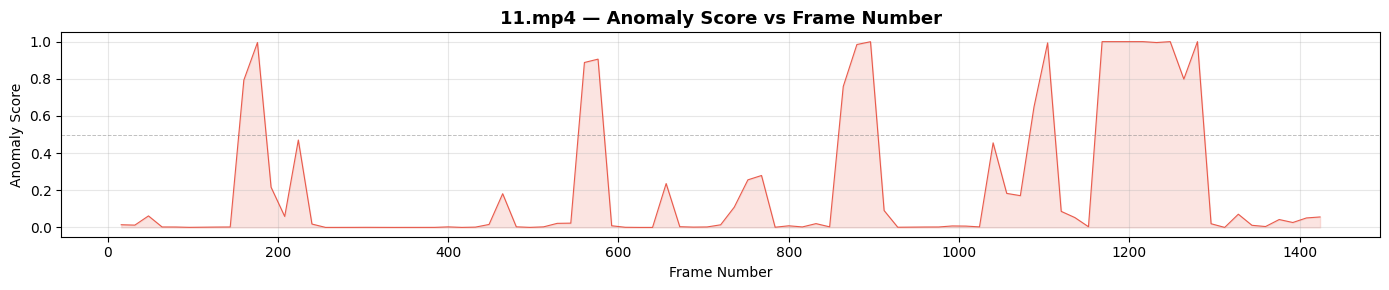

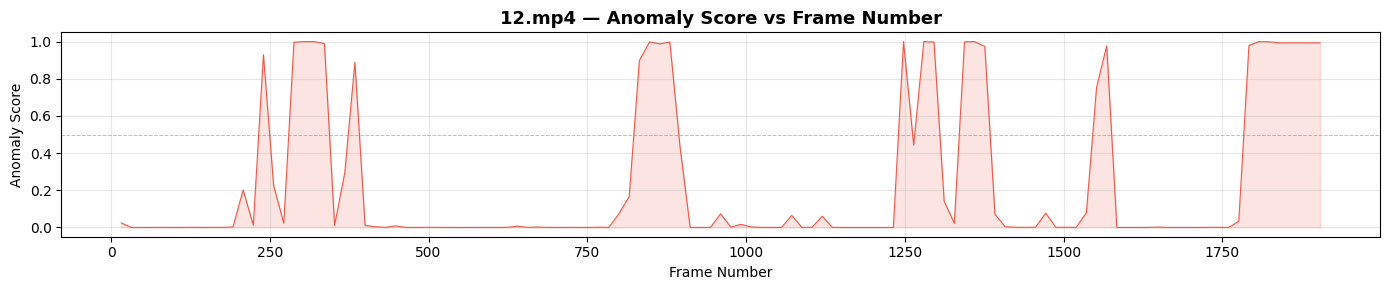

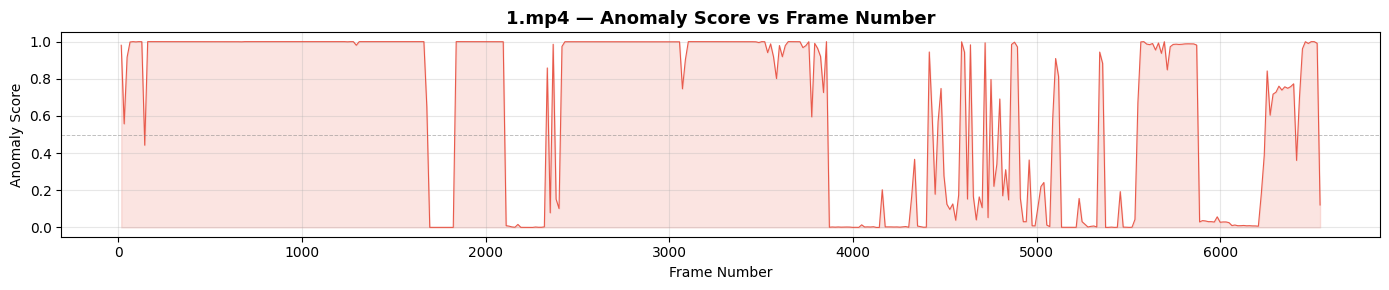

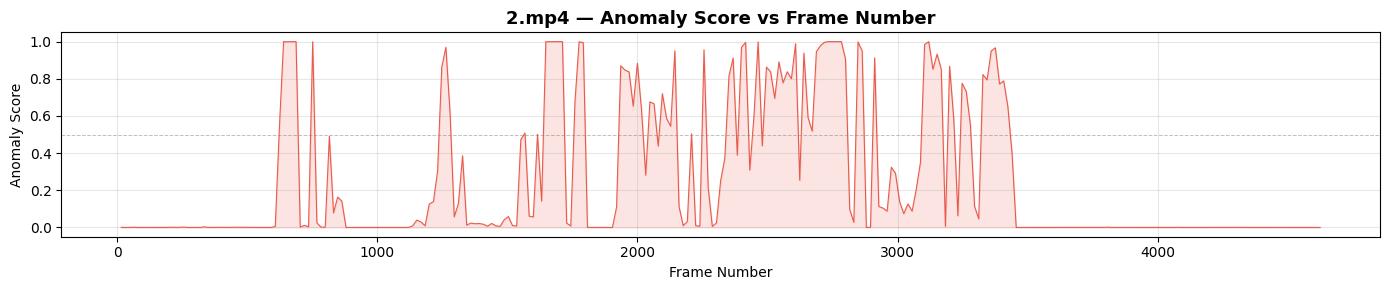

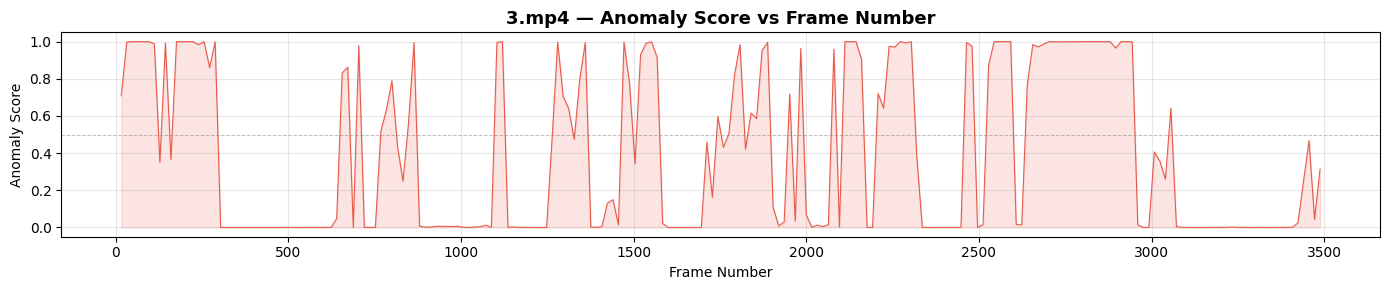

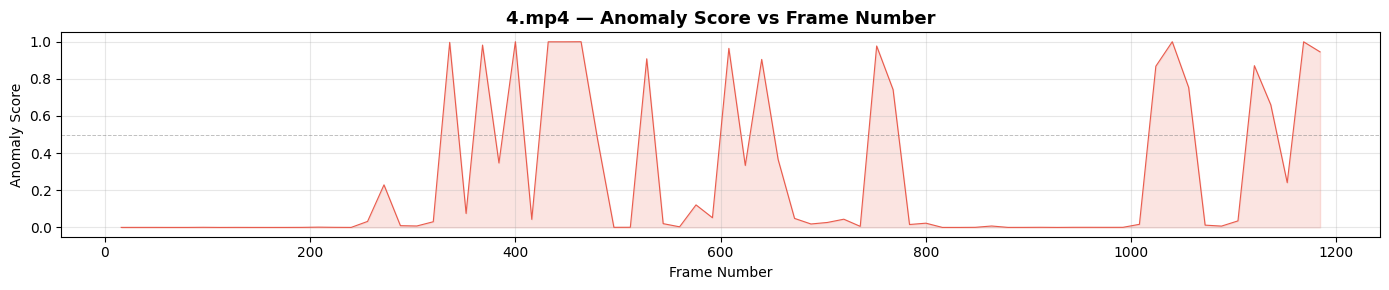

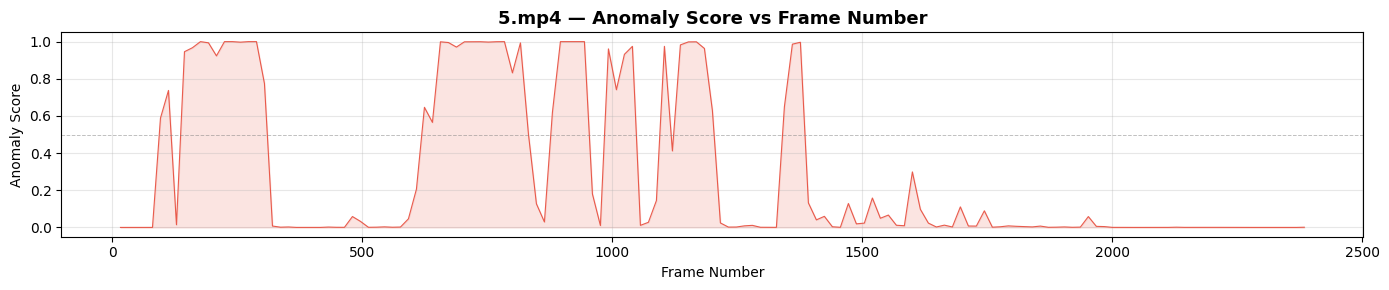

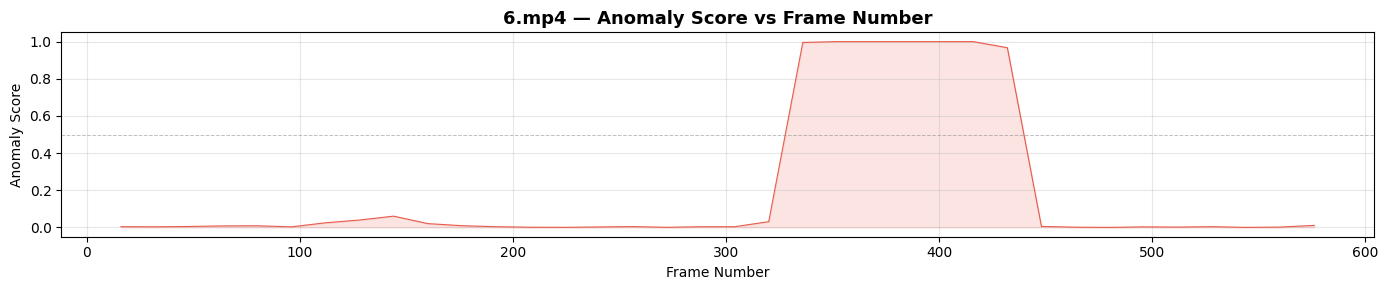

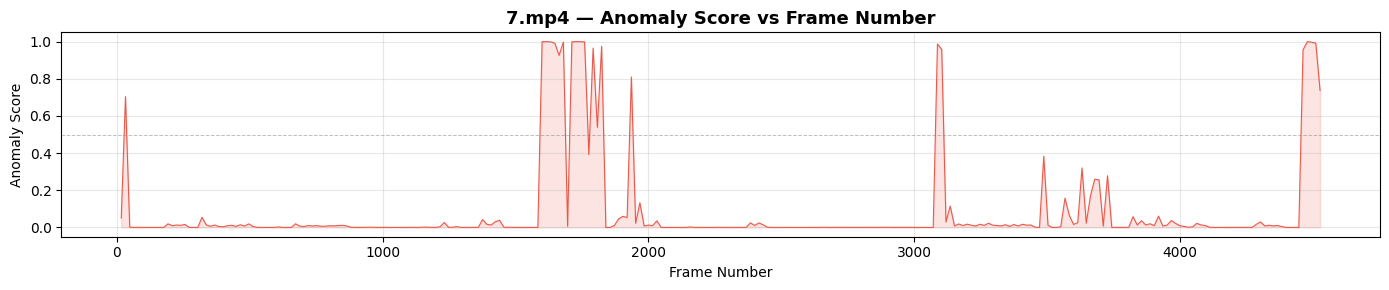

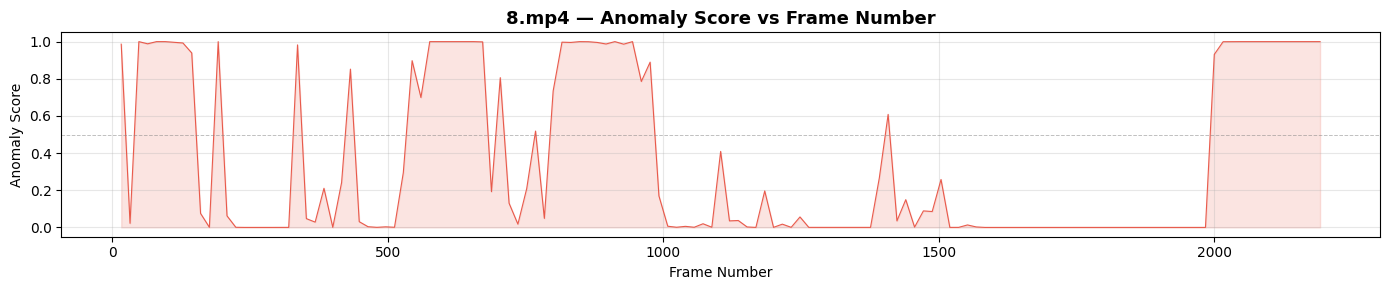

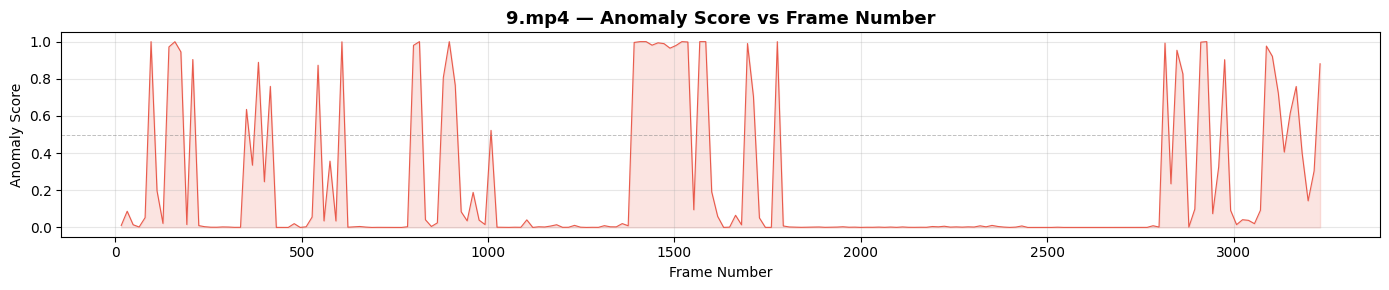

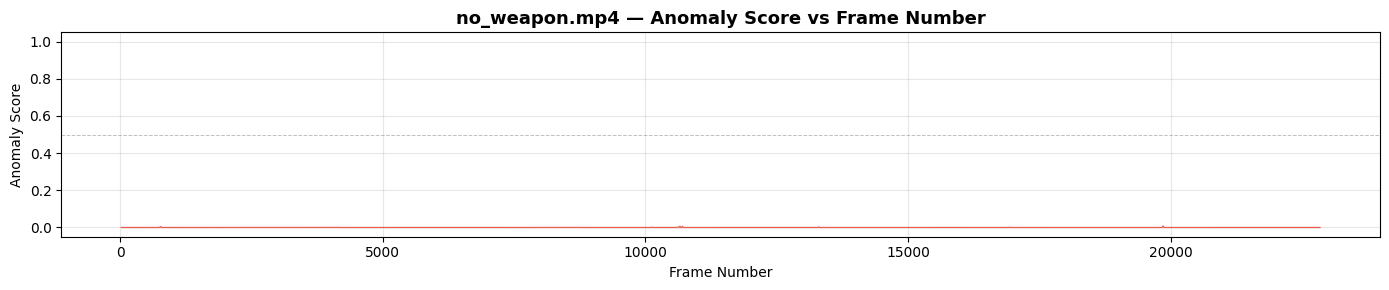

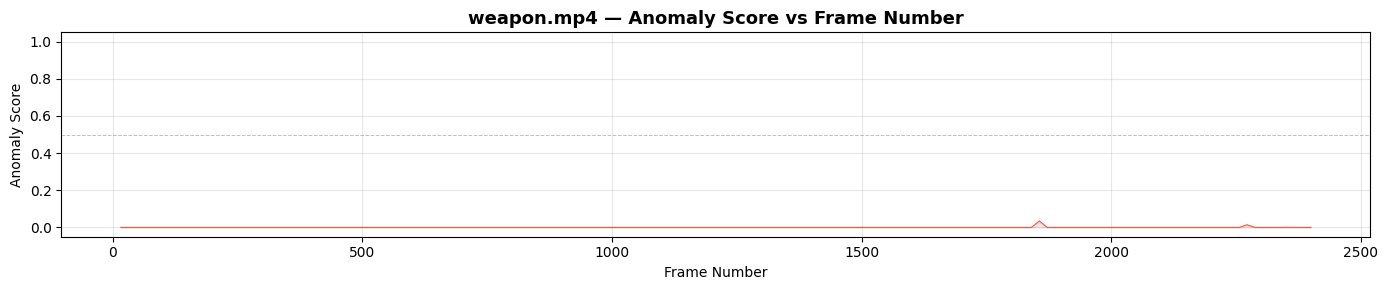

In [ ]:
# Plot anomaly score vs frame number — one figure per video
json_files = sorted(glob.glob(os.path.join(TEST_DIR, "*_anomaly_scores.json")))
print(f"Found {len(json_files)} anomaly score files")

for filepath in json_files:
    with open(filepath, "r") as f:
        data = json.load(f)

    video_name = os.path.basename(data.get("video_source", filepath))
    scores = data.get("scores", [])
    frames = [s["frame"] for s in scores]
    anomaly_scores = [s["anomaly_score"] for s in scores]

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(frames, anomaly_scores, color="#e74c3c", linewidth=0.8, alpha=0.9)
    ax.fill_between(frames, anomaly_scores, alpha=0.15, color="#e74c3c")
    ax.set_title(
        f"{video_name} — Anomaly Score vs Frame Number",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Frame Number")
    ax.set_ylabel("Anomaly Score")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()

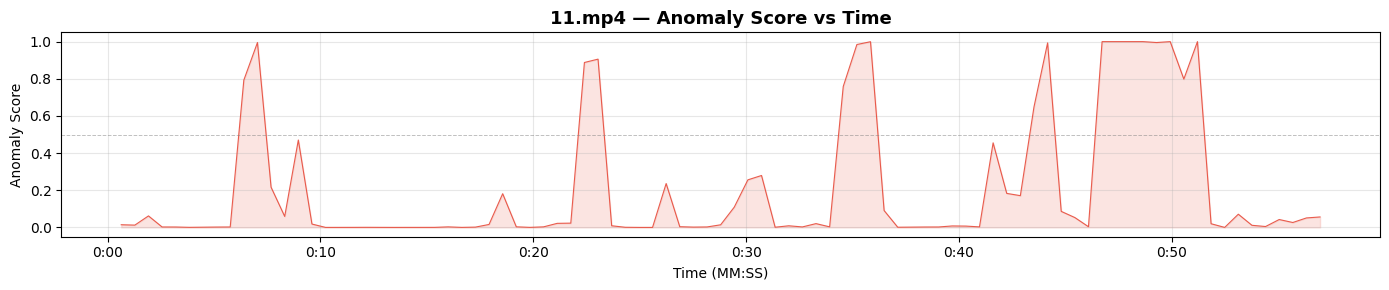

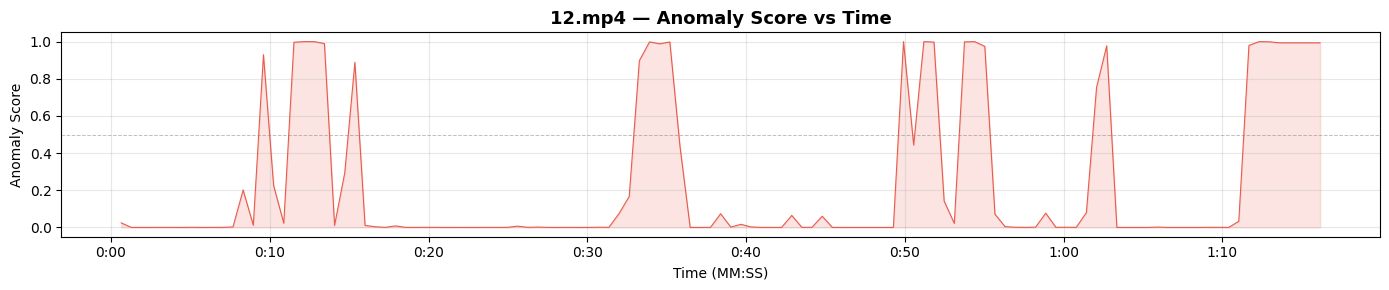

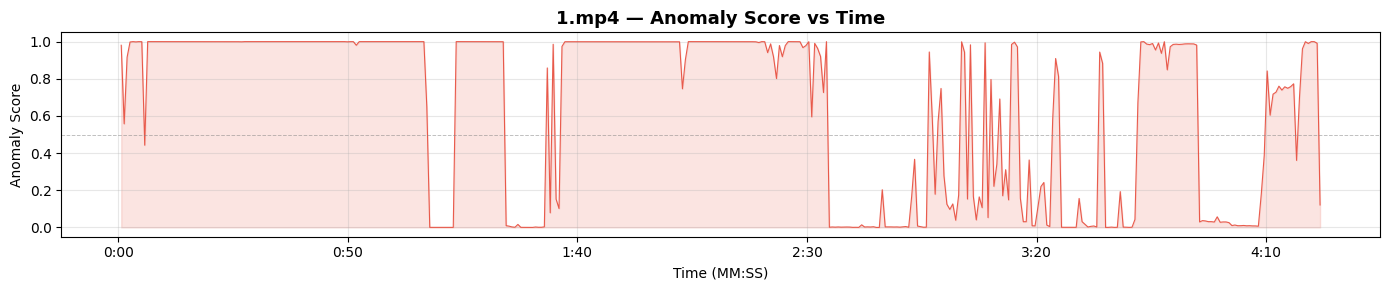

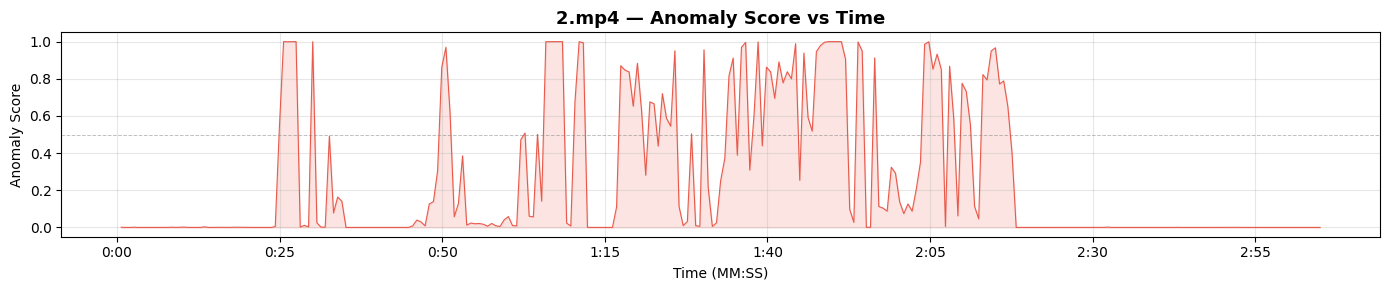

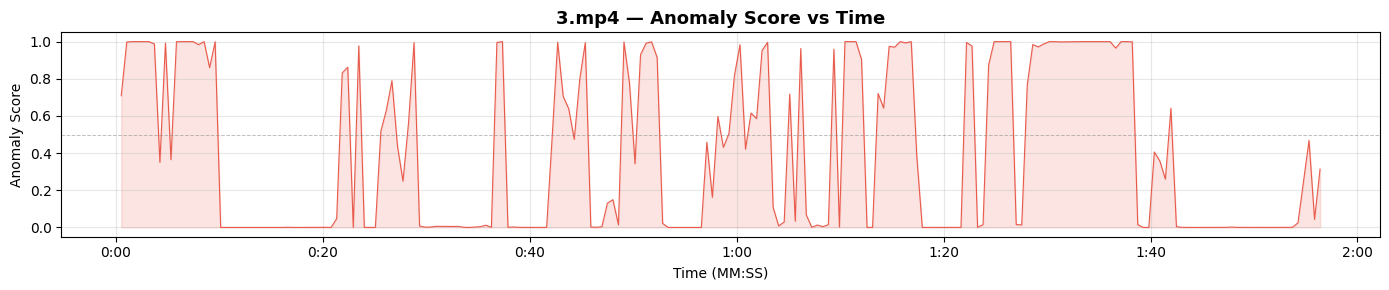

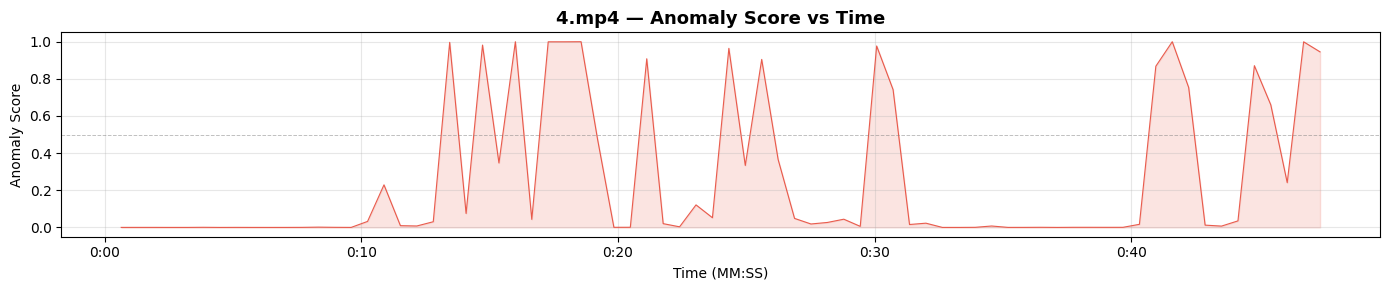

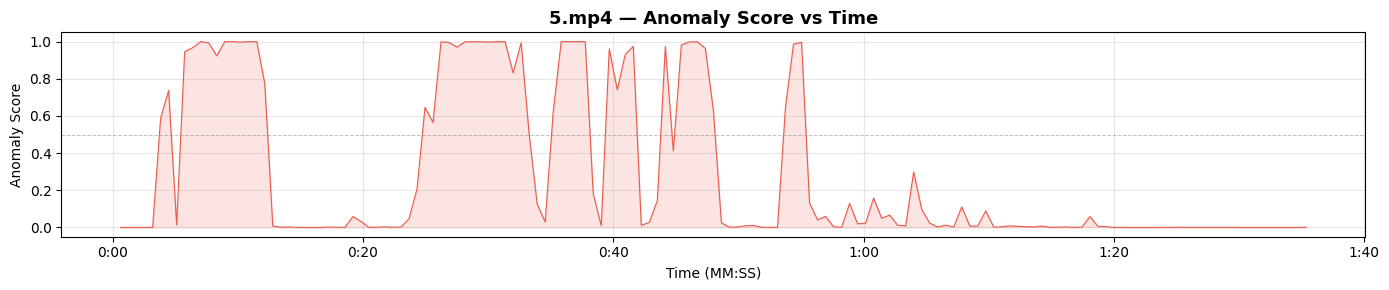

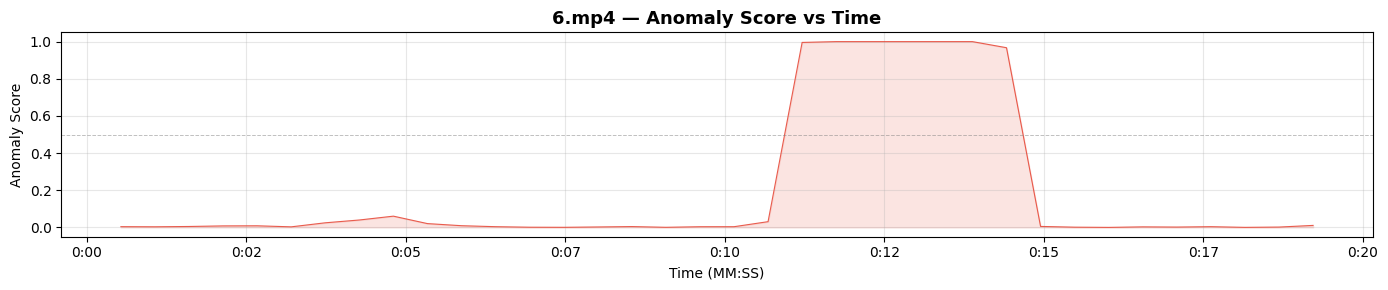

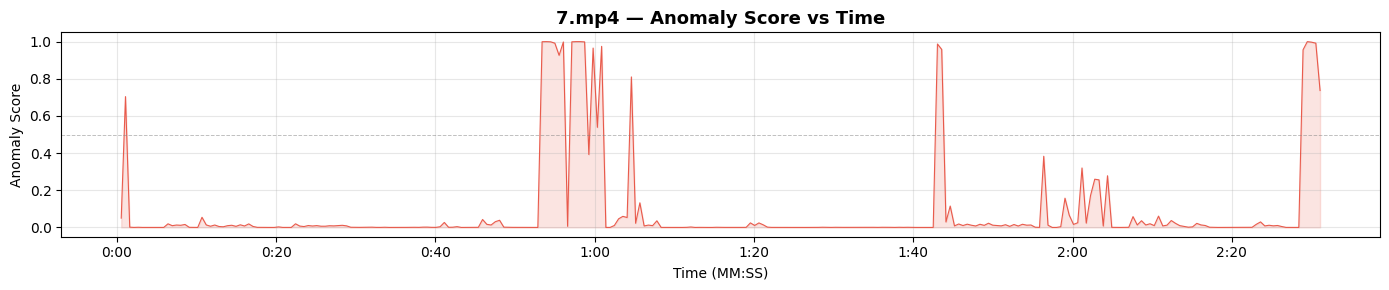

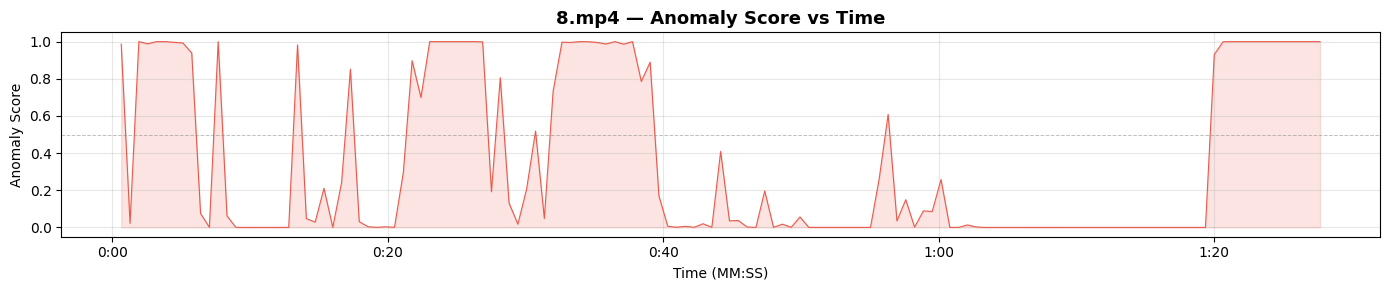

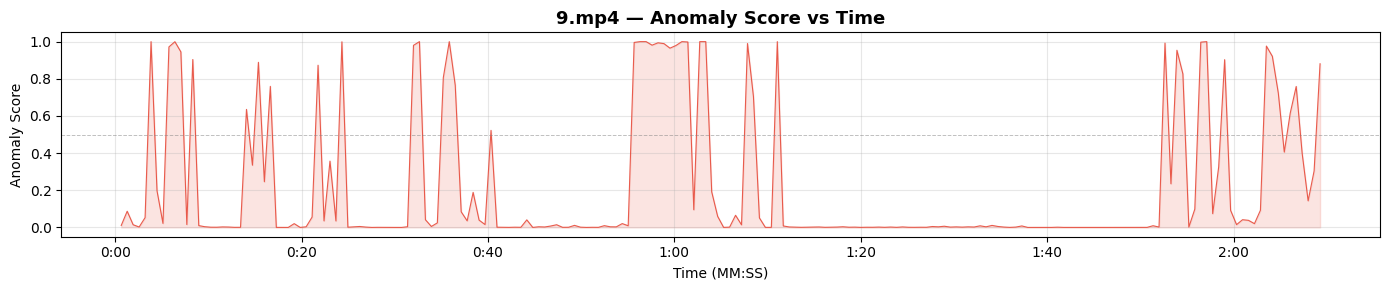

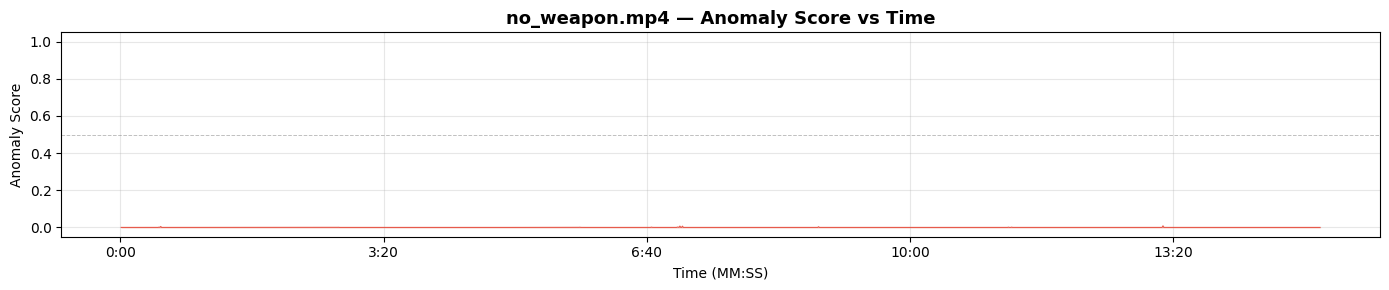

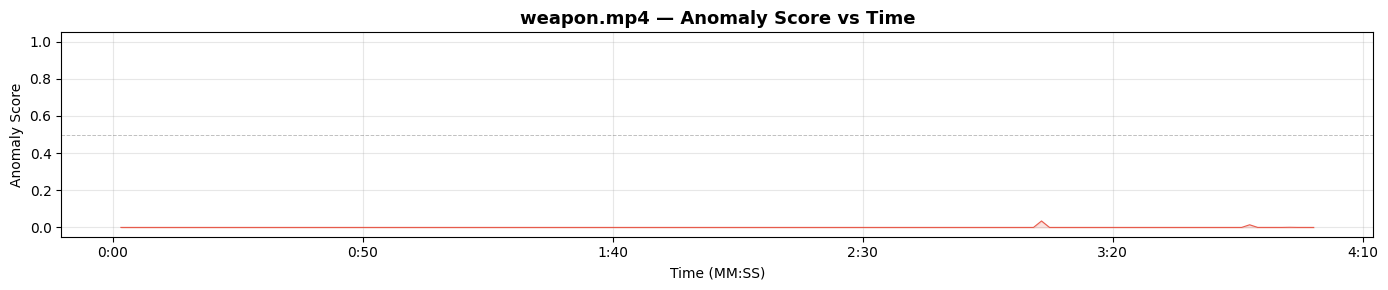

In [7]:
# Plot anomaly score vs time (MM:SS) — one figure per video
def format_time(sec, _):
    m, s = divmod(int(sec), 60)
    return f"{m}:{s:02d}"


for filepath in json_files:
    with open(filepath, "r") as f:
        data = json.load(f)

    video_name = os.path.basename(data.get("video_source", filepath))
    fps = data.get("fps", 30.0)
    scores = data.get("scores", [])
    times = [s["frame"] / fps for s in scores]
    anomaly_scores = [s["anomaly_score"] for s in scores]

    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(times, anomaly_scores, color="#e74c3c", linewidth=0.8, alpha=0.9)
    ax.fill_between(times, anomaly_scores, alpha=0.15, color="#e74c3c")
    ax.set_title(
        f"{video_name} — Anomaly Score vs Time", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Time (MM:SS)")
    ax.set_ylabel("Anomaly Score")
    ax.set_ylim(-0.05, 1.05)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_time))
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
import csv
import glob
import os

import cv2
from ultralytics import YOLO  # type: ignore

DATA_PATH = "test-dataset-4"
MODEL_PATH = "pretrained/yolo26m-weapon-det.pt"
CONFIDENCE = 0.414
output_dir = f"evaluate_yolo_{os.path.basename(DATA_PATH)}"
os.makedirs(output_dir, exist_ok=True)

model = YOLO(MODEL_PATH)

video_paths = glob.glob(
    os.path.join(DATA_PATH, "**", "*.mp4"),
    recursive=True,
)
for video_path in video_paths:
    if str(os.path.basename(video_path)).startswith(("output_", "gradcam_")):
        continue

    cap = cv2.VideoCapture(video_path)

    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Processing video: {video_path}")

    frame_count = 0
    detection_count = 0
    data_csv = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run inference
        results = model.predict(source=frame, conf=CONFIDENCE, verbose=False)
        # Count detections
        if len(results[0].boxes) > 0:  # type: ignore
            detection_count += 1
            data_csv.append([frame_count, "found objects"])

        frame_count += 1
        if frame_count % 1000 == 0:
            print(f"Processed {frame_count}/{total_frames} frames...")

    cap.release()

    print(f"Frames with detections: {detection_count}/{frame_count}")

    # Save to json
    vdo_name, _ = os.path.splitext(os.path.basename(video_path))
    output_csv = os.path.join(
        output_dir,
        f"detection_{vdo_name}.csv",
    )
    with open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["frame", "detection"])
        writer.writerows(data_csv)
